# ML Studio – Session 1  
# Understanding Models Visually

Iman Mossavat

---

A classifier is a function that **divides the input space**.

Different algorithms divide the input space differently.

Today:
- We do not focus on accuracy.
- We focus on **geometry**.
- We compare how models divide the space by *drawing decision boundaries*.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.rcParams["figure.figsize"] = (6, 5)


This is a helper function used to draw 2 dimensional boundaries. Check what `meshgrid` does here. 

In [39]:
def plot_decision_boundary(model, X, y, title="", resolution=300):
    """
    Plot decision boundary using a fixed grid resolution.
    
    resolution: number of points along each axis (controls smoothness)
    """
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Define grid by resolution instead of step size
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=0.1, cmap='bwr')
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

## 1. Linearly Separable Data

Before fitting any model:

- How would *you* separate these points?
- Straight line?
- Curve?


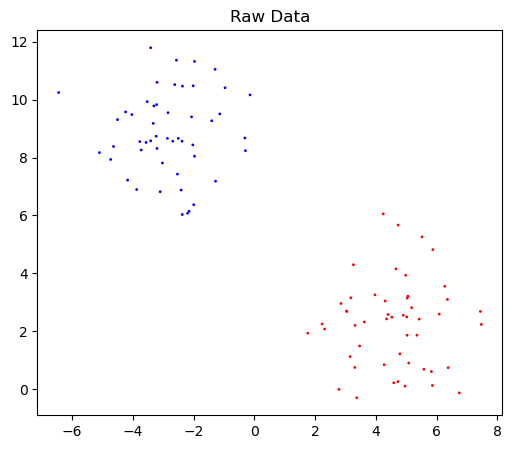

In [50]:
X, y = make_blobs(centers=2, random_state=42, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y,s=1, cmap= 'bwr')
plt.title("Raw Data")
plt.show()


These two variables are our "features" or the columns of your data, each dot is a row of your data. The color is the label of your data. For example, you can imagine x is number of players, and y is the price of a game, so you have two groups of games, group one seem to be cheap and popular games, and group two are expensive and unpopular games. Or you can imagine any other semantics for these data points. 

## Same Data – Different Models

Notice how each model **carves space differently**.


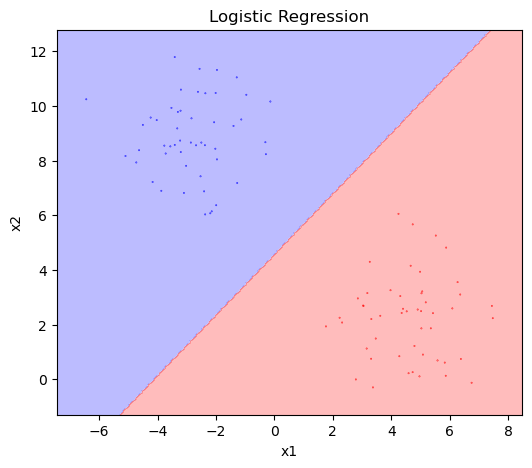

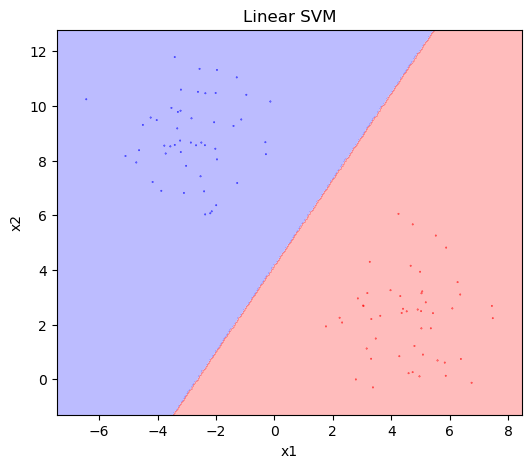

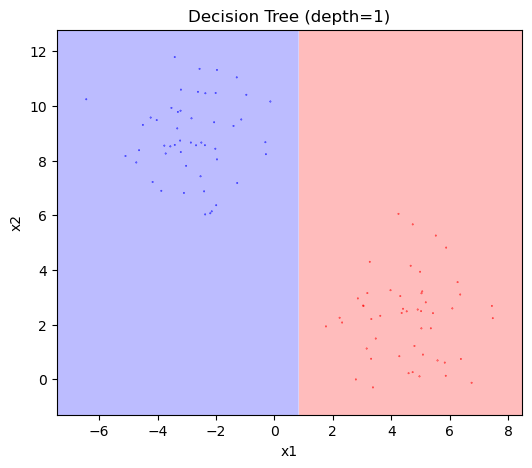

In [51]:
DT_depth= 1
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression()),
    "Linear SVM": make_pipeline(StandardScaler(), SVC(kernel="linear")),
    f"Decision Tree (depth={DT_depth})": DecisionTreeClassifier(max_depth=DT_depth)
}

for name, model in models.items():
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=name)


# Quesiton: 

These are three different algorithms, and they all ended up dividing the space by a line (even the decision tree), but a different line each time. Which line do you think is the best line and why? which one is the worst?

## 2. Nonlinear Geometry – Moons

Now we look into data that is **curved** in its original space. 

**Question**:  Change the noise level and number of data points, how do they affect the problem difficulty in your opinion?


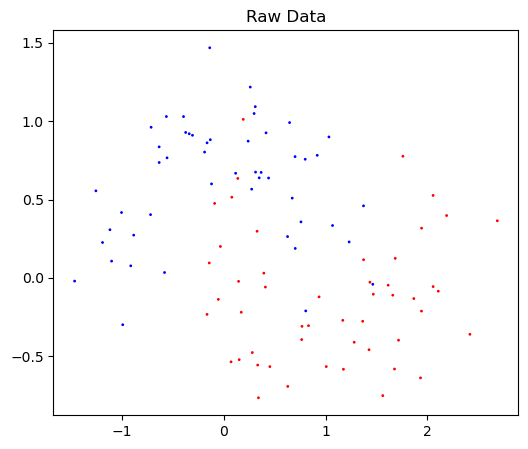

In [52]:
n_samples= 100
noise= 0.25
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)

plt.scatter(X[:, 0], X[:, 1], c=y,s=1, cmap= 'bwr')
plt.title("Raw Data")
plt.show()

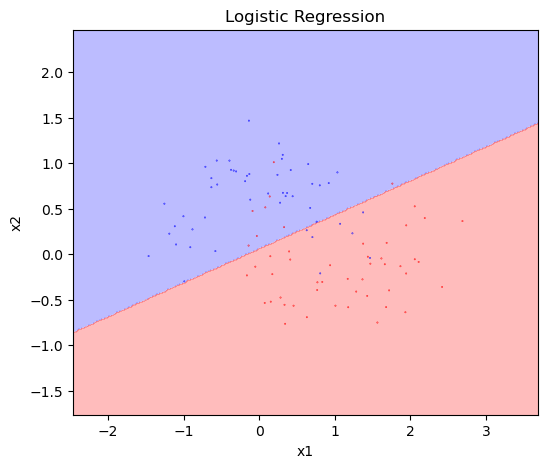

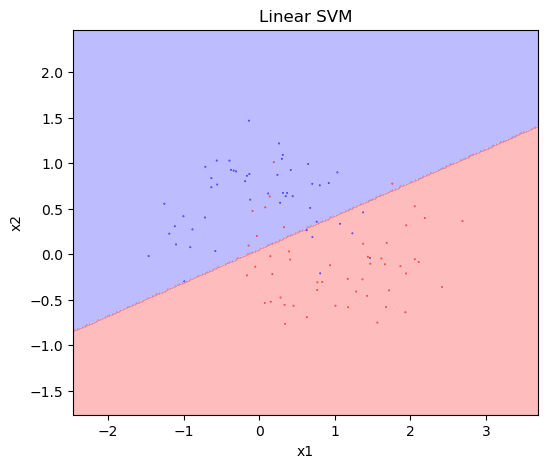

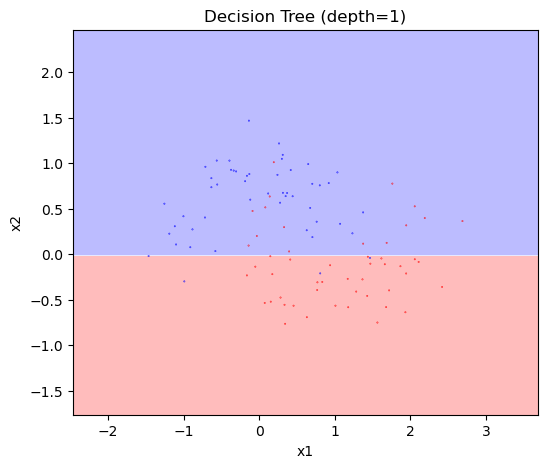

In [53]:
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)

for name, model in models.items():
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=name)


You see that the data is not separable successfully by these models. For linear SVM and logistic regression there is not much that can be done, for decision trees, you can make them more "flexible" by changing their **hyper-parameters** for example `max_depth`.

**Question**: Change the `max_depth` one by one or in a loop what do you see happening?
If you cannot get a good result, try out a simpler data generation setting (more data and less noise)

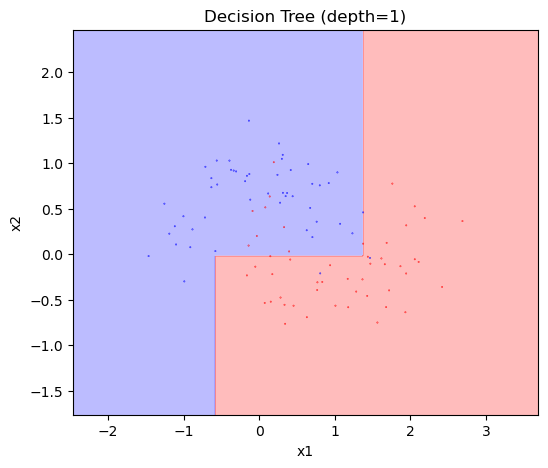

In [84]:
# we regenrate the data for ease- of experimentation
n_samples= 100
noise= 0.25
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)


DT_max_depth= 3


model =  DecisionTreeClassifier(max_depth=DT_max_depth)
model.fit(X, y)
plot_decision_boundary(model, X, y, title=name)

So we need non-linear models, and those that can use their flexibility correclty, unlike a single tree.

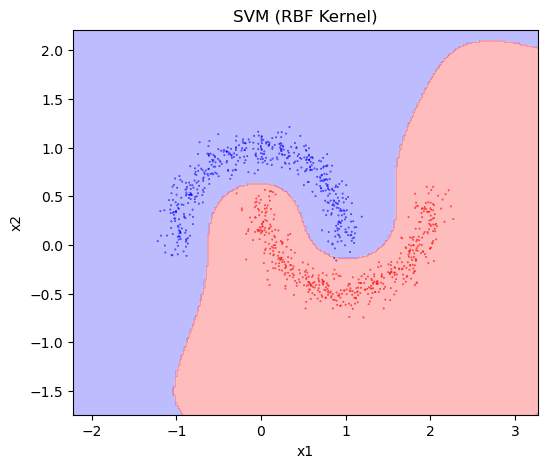

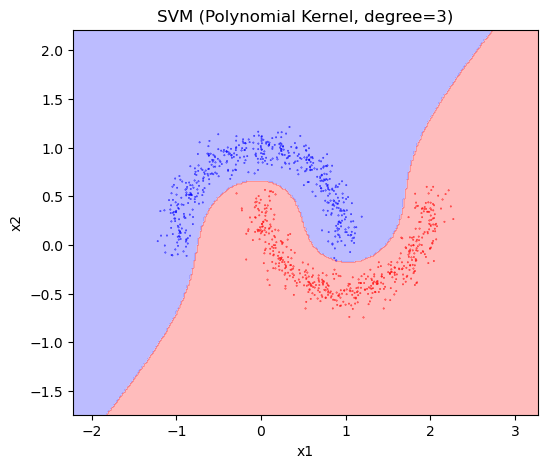

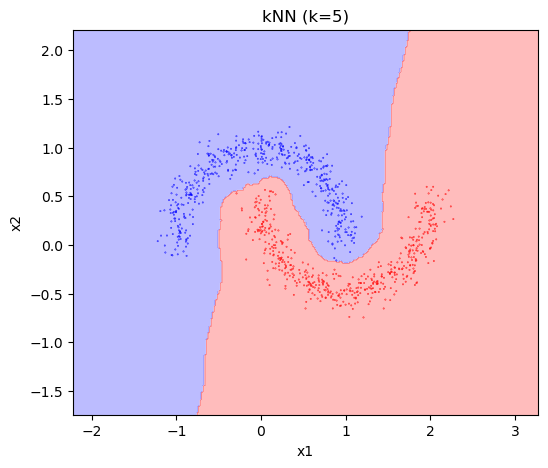

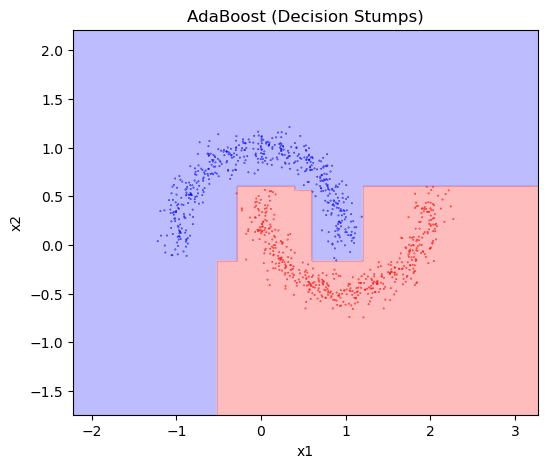

In [ ]:
n_samples= 100
noise= 0.2
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)


from sklearn.ensemble import AdaBoostClassifier

models = {
    "SVM (RBF Kernel)": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", gamma="scale", C=1)
    ),

    "SVM (Polynomial Kernel, degree=3)": make_pipeline(
        StandardScaler(),
        SVC(kernel="poly", degree=3, coef0=1, C=1)
    ),

    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),

    "AdaBoost (Decision Stumps)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=2
        ),
        n_estimators=100,
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=name)


## 3. Controlling Complexity

Flexibility changes the boundary.

What happens if we increase model capacity?


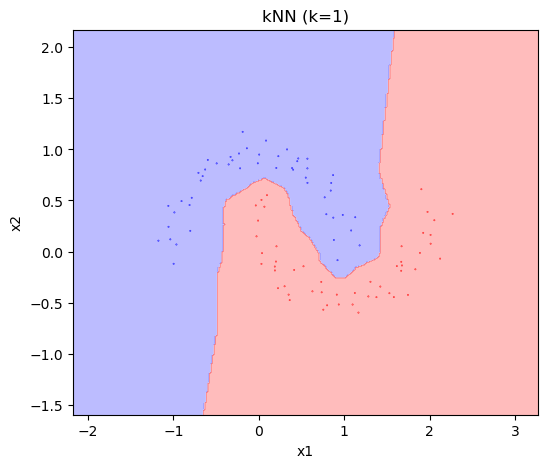

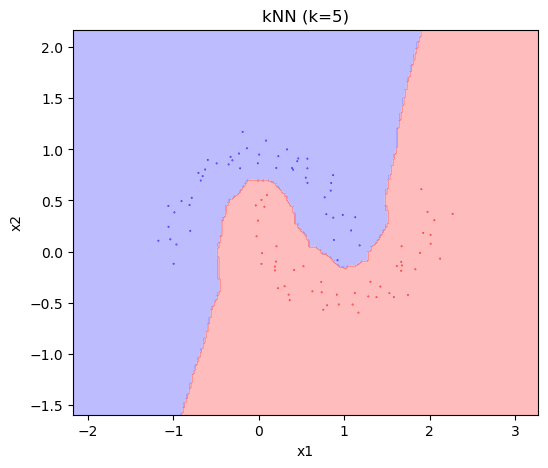

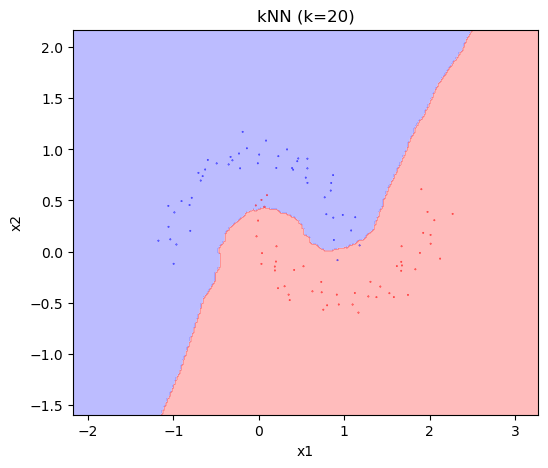

In [94]:
# kNN complexity
n_samples= 100
noise= 0.1
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)



for k in [1, 5, 20]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=f"kNN (k={k})")


**Question**: Read the definition of kNN and find explain what happens when you change the number of neighbors. 



## 4. Changing Representation

All previous models operated directly in the original input space $(x_1, x_2)$.

They carved decision boundaries in that space.

But what if we **transform the space first**?

---

### A Single Neuron as a Transformation

A neuron first mixes the inputs linearly:

$$
z = w_1 x_1 + w_2 x_2 + b
$$

This is a weighted combination of the inputs (plus a bias). 

Then a nonlinear *activation* function $\sigma(\cdot)$ is applied:

$$
y = \sigma(z)
$$

Common activation functions include:

- ReLU  
- Sigmoid  
- Hyperbolic tangent (tanh)

---

### What Does This Mean Geometrically?

The linear part defines a line in $(x_1, x_2)$ space.

The nonlinear activation bends or reshapes the output.

A neuron therefore:

- Computes a projection  
- Applies a nonlinearity  
- Produces a **new feature**

It creates a new, learned data column —  
a new coordinate in a transformed representation space.

 
We are now **reshaping the space itself**.


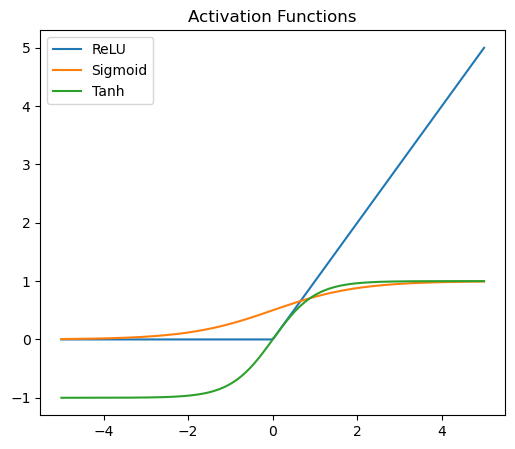

In [99]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

# sample grid
x = np.linspace(-5, 5, 200)
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")
plt.legend()
plt.title("Activation Functions")
plt.show()


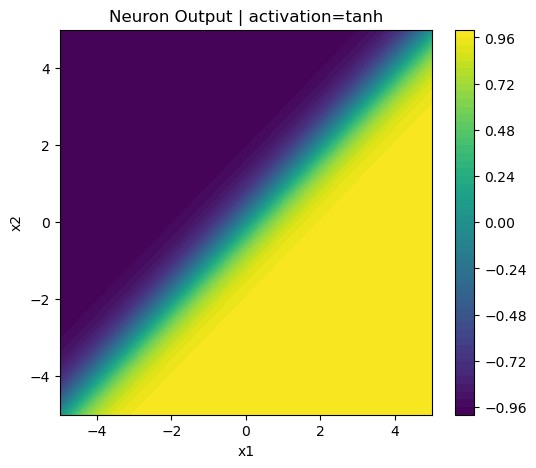

In [100]:
# ------------------------------------------------------------
# Adjustable parameters (change these)
# ------------------------------------------------------------

w1 = 1.0
w2 = -1.0
b  = 0.0

activation_name = "tanh"   # try: "linear", "relu", "sigmoid", "tanh"

# ------------------------------------------------------------
# Activation functions
# ------------------------------------------------------------

def linear(z):
    return z

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

activations = {
    "linear": linear,
    "relu": relu,
    "sigmoid": sigmoid,
    "tanh": tanh
}

activation = activations[activation_name]

# ------------------------------------------------------------
# Create grid in input space
# ------------------------------------------------------------

resolution = 300

x1 = np.linspace(-5, 5, resolution)
x2 = np.linspace(-5, 5, resolution)
xx1, xx2 = np.meshgrid(x1, x2)

# Linear combination
z = w1 * xx1 + w2 * xx2 + b

# Apply activation
y = activation(z)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))
plt.contourf(xx1, xx2, y, levels=50)
plt.colorbar()
plt.title(f"Neuron Output | activation={activation_name}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Here the color is the value of the new data column, or the new feature. 

What is the use of this idea? A single neuron cannot do much, but when you make a huge network of connected neurons, they can change the shape of the data such that classes become easily separable. 

Knowing what a single Neuron does, you are equiped to watch this notebook on neural networks.

https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.01&regularizationRate=0&noise=0&networkShape=4,2&seed=0.87056&showTestData=false&discretize=false&percTrainData=80&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&activation_hide=false